Gianluca Gisolo

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs 
import numpy as np

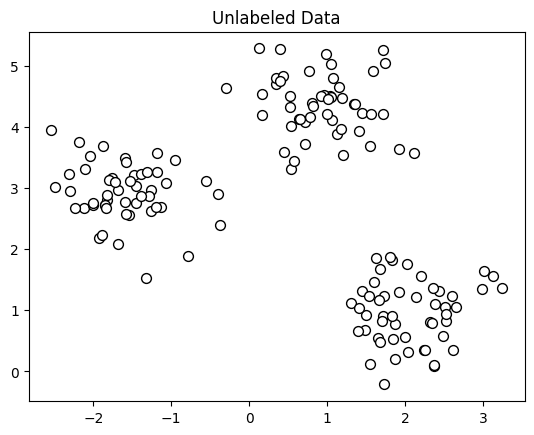

================= Problem 2 =================


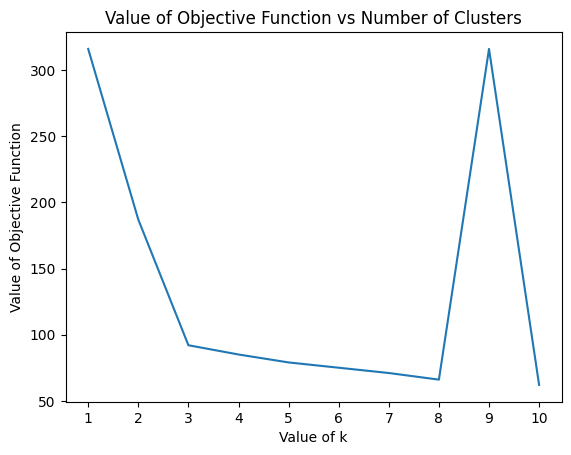

================= Problem 1 =================


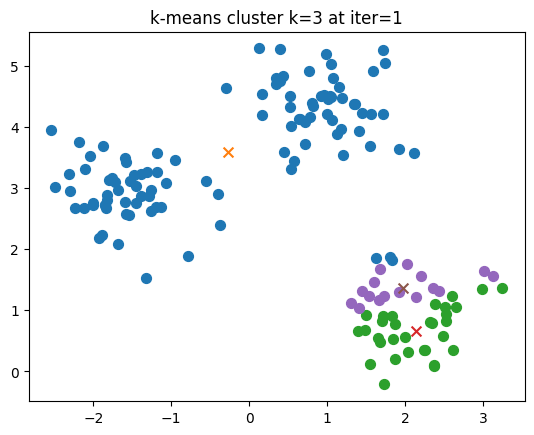

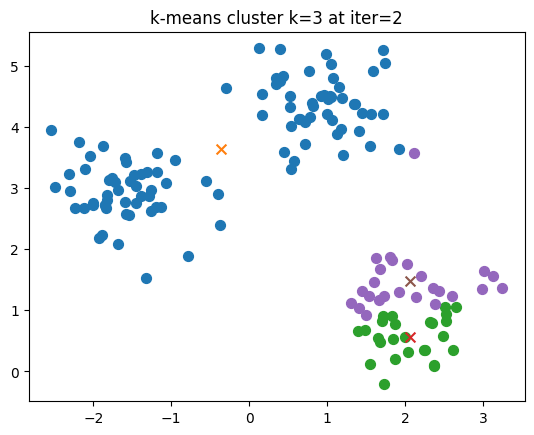

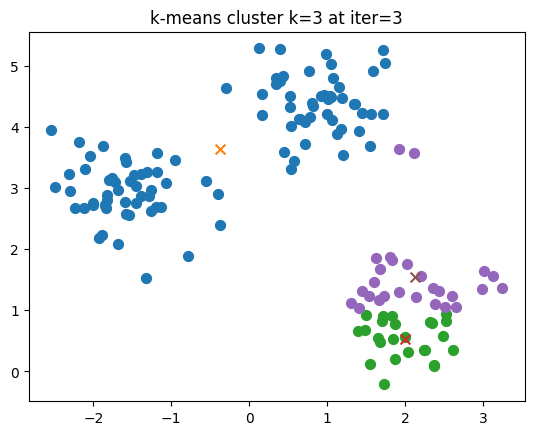

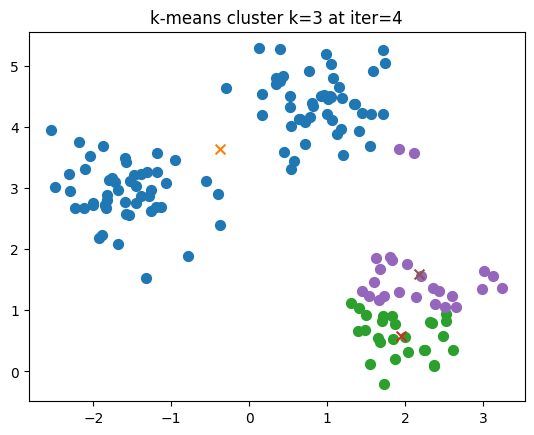

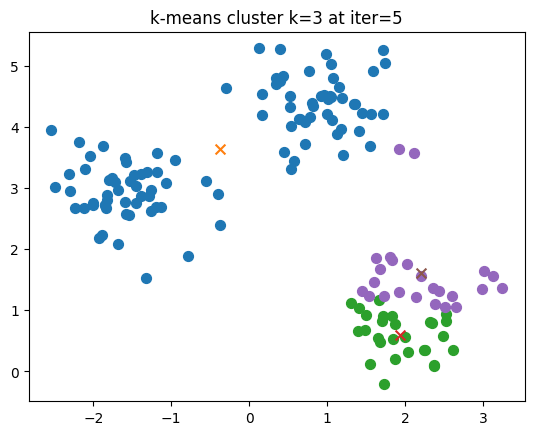

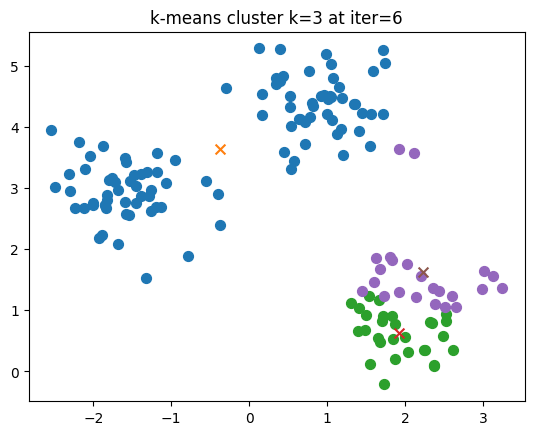

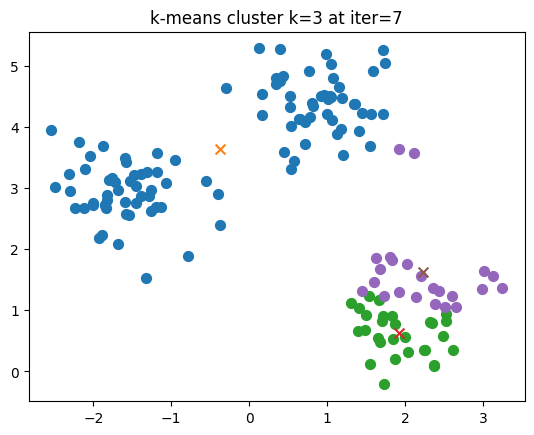

Centers are:
[[-0.37874722  3.63900334]
 [ 1.927178    0.62029237]
 [ 2.23485662  1.62116253]]
Cluster Assignment by index:
[2 0 0 0 1 0 0 1 0 0 2 0 0 0 0 0 0 1 0 1 0 2 0 0 0 1 2 0 0 1 0 0 0 0 0 2 2
 2 0 0 0 0 0 1 2 1 0 2 0 0 2 0 0 1 2 0 0 2 0 0 0 0 0 0 0 0 0 2 0 0 0 2 1 0
 1 0 0 0 0 0 1 1 0 0 2 2 2 0 0 1 1 0 1 0 1 2 0 0 1 2 1 1 0 1 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 2 0 0 2 2 0 1 0 0 0 0 1 0 0 0 0 0 2 0 0 0 1 1 0 0 0 0
 1 1]


In [6]:
def _k_means_clustering_break_cond(
        iter, max_iter, cluster_class,
        prev_cluster_class, tol
    ):
    '''
        Convergence condition for K-means clustering
        The exact exit condition is to check whether
        the cluster classification has NOT changed
        between iteration.
    '''
    return (iter < max_iter) and (
        (   
            np.linalg.norm(
                cluster_class-prev_cluster_class,
                ord=np.inf
            )
        ) > tol
    )

def k_means_clustering(X,k,max_iter=100,tol=1e-10,graphAllIter=False):
    '''
        K-means Custering Function
        Given number of clusters k and
        Given X of size (n,d) where
            n is the number of data points
            d is the dimension of each data point
        Returns the centers of k clusters as a
        (k,d) array and an (n,) array of
        cluster classification by index
    '''
    # Randomly choose initial cluster centers
    index = np.random.choice(X.shape[0], k)
    # Centered is flattened and X is tiled to
    # compute differences via broadcast
    centers = X[index].flatten() 
    X_tiled = np.tile(X, k)

    # Initialize cluster classification arrays
    cluster_class = np.zeros(X.shape[0])
    prev_cluster_class = np.inf*np.ones(X.shape[0])
    iii = 0 # iteration index
    while _k_means_clustering_break_cond(
            iii, max_iter, cluster_class,
            prev_cluster_class, tol
        ):
        iii += 1
        prev_cluster_class = cluster_class

        # === One line version in file header ===
        # Computes difference between centers
        # and data stored as (n*k,d)
        all_diff = (X_tiled-centers).reshape(
            (-1,X.shape[-1])
        )
        # Computes distances between centers
        # and data stored as (n,k)
        all_dist = np.linalg.norm(
            all_diff, axis=1
        ).reshape((X.shape[0],k))
        # Determines the cluster with minimal
        # distance to center, stored as (n,)
        cluster_class = np.argmin(all_dist,axis=1)
        # ============= end one line =============

        for i in range(k):
            # Calculates new centers based on index
            centers[i*X.shape[-1]:(i+1)*X.shape[-1]] = np.average(
                X[cluster_class == i], axis=0
            )
        if graphAllIter:
            for i in range(k):
                # graphs the data in a cluster
                plt.scatter(
                    (X[cluster_class == i])[:,0],
                    (X[cluster_class == i])[:,1],
                    marker='o', s=50
                )
                # graphs the centers
                plt.scatter(
                    centers[i*X.shape[-1]],
                    centers[i*X.shape[-1] + 1],
                    marker='x', s=50
                )
            plt.title(
                f'k-means cluster k={k} at iter={iii}'
            )
            plt.show()
    return centers.reshape((k,X.shape[-1])), cluster_class

def problem_1(X,k=3, graphAllIter=True):
    # Does problem 1
    centers, cluster_class = k_means_clustering(
        X,k=k,graphAllIter=graphAllIter
    )
    print('Centers are:')
    print(centers)
    print('Cluster Assignment by index:')
    print(cluster_class)
    # Note if graphAllIter is True
    # The last plot produced by
    # k_means_clustering will be the
    # same plot as the following code
    # So the follow condition will be
    # opposite to the k_means_clustering
    # condition
    if not graphAllIter:
        for i in range(k):
            # graphs the data in a cluster
            plt.scatter(
                (X[cluster_class == i])[:,0],
                (X[cluster_class == i])[:,1],
                marker='o', s=50
            )
            # graphs the centers
            plt.scatter(
                centers[i,0],
                centers[i,1],
                marker='x', s=50
            )
        plt.title(f'k-means cluster k={k}')
        plt.show()

    

def k_means_obj_fxn(X, centers,cluster_class):
    '''
        Given data X, centers, and associated
        cluster classification computes the
        K-means cluster objective function.
    '''
    L = 0
    for i in range(centers.shape[0]):
        L += np.sum(np.linalg.norm(
            X[cluster_class == i] - centers[i],
            axis=1
        ))
    return L


def problem_2(X,to_check=10):
    # Does problem 2
    k_values = np.array(range(1,to_check+1))
    L_values = np.empty_like(k_values)
    for k in k_values:
        centers, cluster_class = k_means_clustering(
            X,k=k
        )
        L_values[k-1] = k_means_obj_fxn(
            X,centers,cluster_class
        )
    plt.plot(k_values, L_values)
    plt.xticks(k_values)
    plt.xlabel(f'Value of k')
    plt.ylabel(f'Value of Objective Function')
    plt.title(
        'Value of Objective Function vs Number of Clusters'
    )
    # print(np.argpartition(L_values[:-1] - L_values[1:],-3)[-3:])
    plt.show()

def hw4():
    # create dataset
    X, y = make_blobs(
        n_samples=150, n_features=2,
        centers=3, cluster_std=0.5,
        shuffle=True, random_state=0
    )
    # plot
    plt.scatter(X[:, 0], X[:, 1], c='white', marker='o', edgecolor='black', s=50)
    plt.title('Unlabeled Data')
    plt.show()

    # np.random.seed(0) # For fixed seeding
    print('================= Problem 2 =================')
    problem_2(X)
    print('================= Problem 1 =================')
    problem_1(X,k=3, graphAllIter=True)
    return
hw4()